In [ ]:
import sys

import numpy as np # type: ignore
import matplotlib.pyplot as plt # type: ignore
import scipy as sp # type: ignore
import pandas as pd

import os

from tqdm import tqdm # type: ignore
import struct

In [2]:
dir = r"D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2"

header = "UODE32_3_"
footer = ".csv"

flist = []
for _ in os.listdir(dir):
    if not header in _:
        continue
    elif not footer in _:
        continue
    flist.append(_)

flist.sort(key = (
    lambda x: int(x.replace(header, "").replace(footer, ""))
))
filenames = list(map(lambda x: os.path.join(dir, x), flist))


for f in filenames:
    print(f)

D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_0.csv
D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_1.csv
D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_2.csv
D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_3.csv
D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_4.csv
D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_5.csv
D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_6.csv
D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_7.csv
D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_8.csv
D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_9.csv
D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_10.csv
D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_11.csv
D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_12.csv
D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_13.csv
D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_14.csv
D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_15.csv
D:\DATA\SPring-8-2

In [3]:
xrd_profiles = []
for f in filenames:
    print(f)
    df = pd.read_csv(f, header = None)
    xrd_profiles.append(df.values.T[1])
tth = df.values.T[0]
xrd_prifiles = np.stack(xrd_profiles)

D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_0.csv
D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_1.csv
D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_2.csv
D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_3.csv
D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_4.csv
D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_5.csv
D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_6.csv
D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_7.csv
D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_8.csv
D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_9.csv
D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_10.csv
D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_11.csv
D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_12.csv
D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_13.csv
D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_14.csv
D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_15.csv
D:\DATA\SPring-8-2

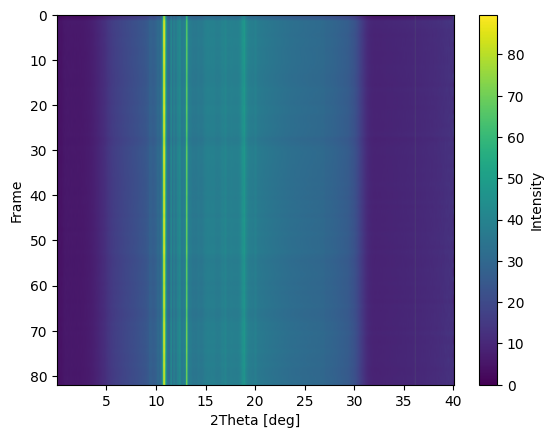

In [4]:
plt.imshow(
    xrd_profiles,
    extent = [tth[0],tth[-1],len(filenames), 0],
    aspect = "auto"
    )
plt.ylabel("Frame")
plt.xlabel("2Theta [deg]")
plt.colorbar().set_label("Intensity")
plt.show()
plt.close()

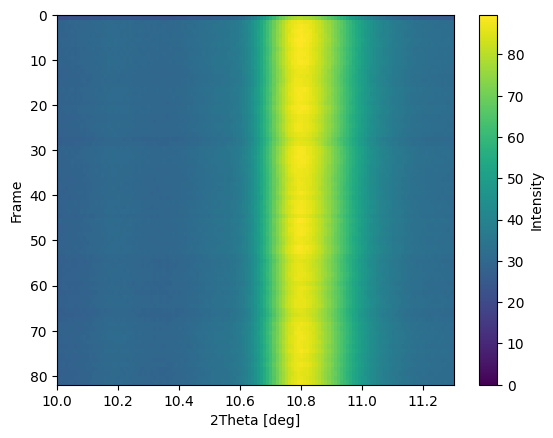

In [5]:
tth_range = (10,11.3)
mask = (tth > tth_range[0])&(tth < tth_range[1])
plt.imshow(
    xrd_profiles,
    extent = [tth[0],tth[-1],len(filenames), 0],
    aspect = "auto"
    )
plt.ylabel("Frame")
plt.xlim(tth_range)
plt.xlabel("2Theta [deg]")
plt.colorbar().set_label("Intensity")
plt.show()
plt.close()

https://sabopy.com/py/lmfit-21/

In [ ]:
import sys
sys.dont_write_bytecode = True # cacheを出さない

import numpy as np # type: ignore
from PIL import Image as im # type: ignore
import matplotlib.pyplot as plt # type: ignore
import matplotlib # type: ignore
import scipy as sp # type: ignore

import tkinter as tk
from tkinter import ttk
import json
import os
from pprint import pprint

from tqdm import tqdm # type: ignore

class peakfit:    
    def __init__(self,
                 theta: np.ndarray = None,
                 intensity: np.ndarray = None,
                 ) -> None:
        """peakをフィットするクラス"""
        self.theta = theta # 1次元
        self.intensity = intensity # shape = (frame, theta)
        return

    def pick_max(self):
        """argmaxを取ってくる"""
        value = self.theta[np.argmax(self.intensity, axis=1)]
        return value
    
    def calc_init(self = None,
                  nop = 1,
                  frame = 0,
                  theta = None,
                  intensity = None,
                  ):
        
        if intensity is not None:
            d_copy = intensity.copy()
        else:
            d_copy = self.intensity[frame].copy()

        if theta is not None:
            tth = theta.copy()
        else:
            if self.theta is not None:
                tth = self.theta
            else:
                tth = np.arange(d_copy.shape[0])


        _a0 = (d_copy[-1]-d_copy[0])/(tth[-1]-tth[0])
        _b0 = d_copy[0]-_a0*tth[0]
        initparams = [
            _b0,
            _a0
        ]
        d_copy -= _a0*tth[0] + _b0
        for _ in range(nop):
            initparams += [
                d_copy.max()-d_copy.min(), # amp
                tth[d_copy.argmax()], # mu
                (tth[-1]-tth[0])/4, # fwhm_g
                (tth[-1]-tth[0])/4, # fwhm_l
                0.5
            ]
            d_copy -= pseudoVoigt(tth, *initparams)
        return initparams

    def fit_Vigot_func(self,
                       frame: int = 0,
                       nop: int = 1,
                       theta: np.array = None,
                       intensity: np.array = None,
                       initparams: list = None, # type: ignore
                       ) -> tuple:

        if intensity is not None:
            d = intensity.copy()
        else:
            d = self.intensity[frame].copy()

        if theta is not None:
            tth = theta.copy()
        else:
            if self.theta is not None:
                tth = self.theta.copy()
            else:
                tth = np.arange(d.shape[0])

        if not initparams:
            if intensity is not None:
                initparams = self.calc_init(intensity = intensity, theta = tth, nop = nop)
            else:
                initparams = self.calc_init(frame = frame, nop = nop)

        methods = ["trf", "dogbox"]

        bounds_up = [np.inf, tth[-1], np.inf, np.inf, 1] * nop
        bounds_down = [0, tth[0], 0, 0, 0] * nop
        bounds = (
            tuple([-np.inf, -np.inf] + bounds_down),
            tuple([np.inf, np.inf] + bounds_up)
        )
        
        for method in methods:
            try:
                func = pseudoVoigt
                (popt, pcov) = sp.optimize.curve_fit(func,
                                                     tth,
                                                     d,
                                                     p0 = initparams,
                                                     maxfev = 4000,
                                                     bounds=bounds,
                                                     method = method,
                                                     )
            except RuntimeError as errorcontent:
                if method == methods[-1]:
                    return errorcontent # type: ignore
                pass
            else:
                res = d - func(tth,*popt)
                rss = np.sum(np.square(res)) # residual sum of squares
                tss = np.sum(np.square(d-np.mean(d))) # total sum of squares = tss
                r_squared = 1 - (rss / tss)
                
                break
        return [popt, np.diag(pcov), r_squared] # type: ignore

    def fit(self,
            nop: int = 1,
            log = True
            ) -> tuple:

        l_popt = []
        l_pcov = []
        l_r2 = []

        loop = tqdm(list(range(self.intensity.shape[0]))) if log else range(self.intensity.shape[0])
        for i in loop:
            _ = self.fit_Vigot_func(frame = i,
                                    nop = nop,
                                    )
            popt = _[0]
            pcov = _[1]
            r_squared = _[2]

            l_popt.append([popt])
            l_pcov.append([pcov])
            l_r2.append(r_squared)

        popts = np.block(l_popt)
        pcovs = np.block(l_pcov)
        r2 = np.array(l_r2)

        return (popts, pcovs, r2)
    
    def variables(self, nop = 1):
        value = ["b0", "b1"]
        value += ["amp", "mu", "fwhm_g", "fwhm_l", "eta"] * nop
        return value

def pseudoVoigt(x, b0, b1, *ps):
    value = b0 + b1*x
    for i in range(len(ps)//5):
        amp = ps[5*i]
        mu = ps[5*i+1]
        fwhm_g = ps[5*i+2]
        fwhm_l = ps[5*i+3]
        eta = ps[5*i+4]

        sigma = fwhm_g/2/np.sqrt(2*np.log(2))
        gamma = fwhm_l/2
        
        g = np.exp(-np.power(x-mu, 2)/2/np.power(sigma,2))
        l = 1/(1+np.power((x-mu)/gamma, 2))

        value += amp*(g*eta + l*(1-eta))
    return value


In [7]:
pf = peakfit()
_res = pf.fit_Vigot_func(
    theta = tth[mask],
    intensity = xrd_prifiles[0][mask]
)

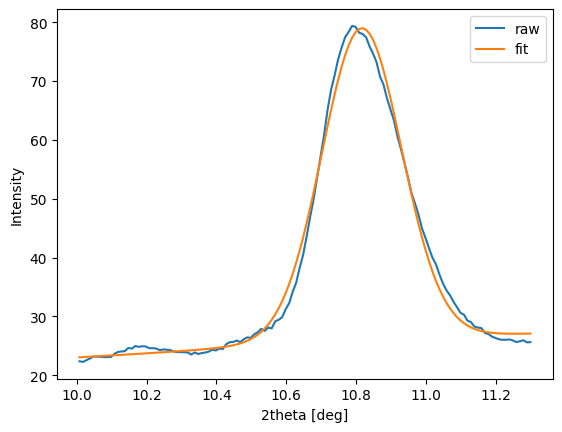

In [8]:
plt.plot(
    tth[mask],
    xrd_prifiles[0][mask],
    label = "raw",
)
plt.plot(
    tth[mask],
    pseudoVoigt(tth[mask], *(_res[0])),
    label = "fit"
)
plt.legend()
plt.xlabel("2theta [deg]")
plt.ylabel("Intensity")
plt.show()
plt.close()

In [9]:
popt = []
pcov = []
r2 = []
for profile in tqdm(xrd_profiles):
    _res = pf.fit_Vigot_func(
        theta = tth[mask],
        intensity = profile[mask]
    )
    _popt = _res[0]
    _pcov = _res[1]
    _r2 = _res[2]

    popt.append(_popt)
    pcov.append(_pcov)
    r2.append(_r2)
popt = np.stack(popt)
pcov = np.stack(pcov)
r2 = np.array(r2)

  0%|          | 0/82 [00:00<?, ?it/s]

100%|██████████| 82/82 [00:06<00:00, 13.17it/s]


In [12]:
df_popt = pd.DataFrame(popt)
df_popt.columns = pf.variables()
output = os.path.join(dir, "popt.csv")
df_popt.to_csv(output)
print(output)

D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\popt.csv


In [13]:
df_pcov = pd.DataFrame(pcov)
df_pcov.columns = pf.variables()
output = os.path.join(dir, "pcov.csv")
df_pcov.to_csv(output)
print(output)

D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\pcov.csv


In [15]:
df_r2 = pd.DataFrame(r2)
output = os.path.join(dir, "r2.csv")
df_r2.to_csv(output)
print(output)

D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\r2.csv
